# Evaluación Final Unidad I — Mi primer proyecto CRISP-DM
**IEI-097 Minería de Datos · Santo Tomás · Trabajo individual**
| | |
|---|---|
| **Nombre completo** | Miguel Ángel Chura Atora |
| **Carrera / Sede / Sección** | Ingeniería en Informática / _(completar sede y sección)_ |
| **Dataset elegido** | Adult (Census Income) — https://archive.ics.uci.edu/dataset/2/adult |

Contenido: A. El problema · B. Los datos · C. EDA y preparación · D. Reglas de asociación · E. Árbol de decisión · F. Síntesis y CRISP-DM · G. Autoría

## A. El problema
**Fase CRISP-DM: Comprensión del negocio.**

**Contexto.** Una institución que diseña programas de capacitación y apoyo laboral necesita saber qué características de las personas se asocian con tener ingresos altos (más de 50.000 USD al año) y cuáles con ingresos bajos.

**Objetivo.** Descubrir qué combinaciones de características (educación, estado civil, ocupación, horas trabajadas, ganancias de capital) se asocian con un ingreso anual superior a 50K, y representar ese conocimiento con **reglas de asociación** y un **árbol de decisión**.

**¿Por qué minería de datos?** Son ~45.000 personas y 10 atributos que se combinan entre sí. Con un resumen manual o una tabla dinámica sólo vemos relaciones de a una variable; la minería de datos permite encontrar combinaciones (por ejemplo "casado + educación superior") y expresarlas como reglas legibles.

## B. Los datos
**Fase CRISP-DM: Comprensión de los datos.**

**Fuente:** Adult (Census Income), UCI Machine Learning Repository — Becker & Kohavi (1996), licencia CC BY 4.0. https://archive.ics.uci.edu/dataset/2/adult. Copia CSV usada aquí: repositorio `jbrownlee/Datasets` en GitHub.

**Cumplimiento de criterios:** tabular CSV con ~48.800 filas, 15 columnas, objetivo categórico de 2 clases (`income`), varias variables categóricas o agrupables en tramos, licencia abierta y registros anónimos (sin nombres ni identificadores). Excluí `race` y `sex` del análisis para no modelar con atributos sensibles.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
cols = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation',
        'relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']
raw = pd.read_csv(URL, header=None, names=cols, skipinitialspace=True)
print(raw.shape)
raw.head()

(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Origen del dataset y por qué lo elegí
**De dónde viene.** El dataset *Adult* (también llamado *Census Income*) lo extrajo Barry Becker de la base de datos del censo de EE.UU. de 1994 y lo donaron Ronny Kohavi y Barry Becker al repositorio UCI Machine Learning Repository en 1996. Su objetivo original es predecir si una persona gana más de 50K al año. Está publicado en https://archive.ics.uci.edu/dataset/2/adult con licencia CC BY 4.0. La copia en CSV que cargo en el notebook está en el repositorio de GitHub `jbrownlee/Datasets`, porque Colab la puede leer directo desde una URL.

**Por qué lo elegí.**
- Cumple todos los criterios de la actividad (tabular, entre 500 y 50.000 filas, 15 columnas, objetivo categórico de 2 clases, varias variables categóricas o agrupables, licencia abierta y fuente citable).
- Es anónimo: no trae nombres ni identificadores de personas.
- Es un conjunto muy conocido y documentado, así que puedo citar la fuente y comparar mis resultados con otros trabajos.
- Tiene variables que se prestan a los dos métodos: categorías (educación, estado civil, ocupación) para las reglas de asociación y una clase objetivo clara para el árbol.
- Tiene problemas reales de calidad (nulos como "?", duplicados, desbalance de clases), lo que permite practicar el EDA y la limpieza.

**Cómo llegué a él y qué verifiqué por mi cuenta.** El dataset lo propuso la herramienta de IA tras buscar fuentes abiertas que cumplieran los criterios. Para dejarlo como decisión mía, lo revisé en la fuente original:
- ☐ Abrí la página oficial de UCI y confirmé el nombre, los autores y la licencia.
- ☐ Leí la descripción de las 15 variables y comprobé el significado de cada una.
- ☐ Comprobé que la copia de GitHub coincide con el dataset de UCI (mismas 48.842 filas y 15 columnas).

_(Marca con ✔ solo lo que hayas hecho y agrega aquí en 2 o 3 líneas qué otras fuentes viste o por qué lo preferiste a otros datasets.)_

### Diccionario de 10 atributos (más la variable objetivo)
| # | Atributo | Tipo | Justificación |
|---|---|---|---|
| 1 | `age` | Numérico | La edad se asocia a la experiencia laboral y al nivel de ingreso. |
| 2 | `workclass` | Categórico | El tipo de empleador (privado, gobierno, independiente) cambia las condiciones de pago. |
| 3 | `education` | Categórico | La formación es uno de los factores más asociados al ingreso. |
| 4 | `marital_status` | Categórico | Se relaciona con la etapa de vida y con hogares de doble ingreso. |
| 5 | `occupation` | Categórico | El tipo de trabajo determina el rango salarial. |
| 6 | `relationship` | Categórico | Posición en el hogar (esposo, hijo, soltero…); complementa al estado civil. |
| 7 | `capital_gain` | Numérico | Ganancias de inversión, que suelen asociarse a mayor patrimonio. |
| 8 | `capital_loss` | Numérico | Pérdidas de inversión; también indica que la persona invierte. |
| 9 | `hours_per_week` | Numérico | Más horas trabajadas pueden implicar mayor ingreso. |
| 10 | `native_country` | Categórico | País de origen; permite ver si hay diferencias entre EE.UU. y otros países. |
| — | `income` | **Objetivo (2 clases)** | `<=50K` / `>50K`. |

Descarté `fnlwgt` (peso estadístico del censo, no describe a la persona), `education_num` (repite `education`), y `race` y `sex` (atributos sensibles).

## C. Exploración y preparación (EDA)
**Fase(s) CRISP-DM: Comprensión de los datos (exploración) y Preparación de los datos (limpieza y descarte).**

In [2]:
print(raw.info())
print("\nValores '?' por columna:")
print((raw == '?').sum()[lambda s: s > 0])
print("\nFilas duplicadas:", raw.duplicated().sum())
print("\nDistribución de la variable objetivo:")
print(raw.income.value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  48842 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB
None

Valores '?' por columna:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Filas dupli

In [3]:
# Limpieza
d = raw.replace('?', np.nan).drop_duplicates()
print("Tras eliminar duplicados:", d.shape)
d = d.dropna(subset=['workclass','occupation','native_country'])
print("Tras eliminar filas con datos faltantes:", d.shape)
d = d[['age','workclass','education','marital_status','occupation','relationship',
       'capital_gain','capital_loss','hours_per_week','native_country','income']].reset_index(drop=True)
d.describe().T

Tras eliminar duplicados: (48790, 15)
Tras eliminar filas con datos faltantes: (45175, 15)


,count,mean,std,min,25%,50%,75%,max
age,45175.0,38.556170,13.215349,17.0,28.0,37.0,47.0,90.0
capital_gain,45175.0,1102.576270,7510.249876,0.0,0.0,0.0,0.0,99999.0
capital_loss,45175.0,88.687593,405.156611,0.0,0.0,0.0,0.0,4356.0
hours_per_week,45175.0,40.942512,12.007730,1.0,40.0,40.0,45.0,99.0


**Hallazgos del EDA (sobre los datos crudos)**
- **Tamaño:** 48.842 filas y 15 columnas; 6 numéricas y 9 categóricas.
- **Nulos:** `info()` dice que no hay nulos, pero es engañoso: los faltantes vienen escritos como `"?"`. Hay 2.799 en `workclass`, 2.809 en `occupation` y 857 en `native_country`.
- **Duplicados:** 52 filas repetidas.
- **Desbalance de clases:** ~76 % `<=50K` y ~24 % `>50K` (en los datos limpios, 75/25).
- **Rangos y valores extraños:** `capital_gain` llega a 99.999 (valor que parece un tope de codificación) y la mayoría tiene 0; `hours_per_week` llega a 99 horas; `fnlwgt` tiene valores hasta 1,49 millones y no describe a la persona.
- **Problemas de calidad detectados:** faltantes codificados como texto, duplicados, columnas redundantes (`education` y `education_num` dicen lo mismo) y columnas sin valor analítico (`fnlwgt`).

**Decisiones de limpieza**
- **Duplicados:** eliminé las filas repetidas porque contarían dos veces a la misma observación y distorsionarían support y conteos.
- **Valores faltantes ("?"):** sólo aparecen en 3 variables categóricas (≈7 % de las filas). Eliminé esas filas en vez de imputarlas porque quedan ~45.000 registros, de sobra, y no quería inventar una ocupación o clase de trabajo.
- **Columnas descartadas:** ver diccionario en la parte B.

/tmp/ipykernel_229/674168325.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='income', y='hours_per_week', ax=ax[2], palette=['#4C72B0','#DD8452'])


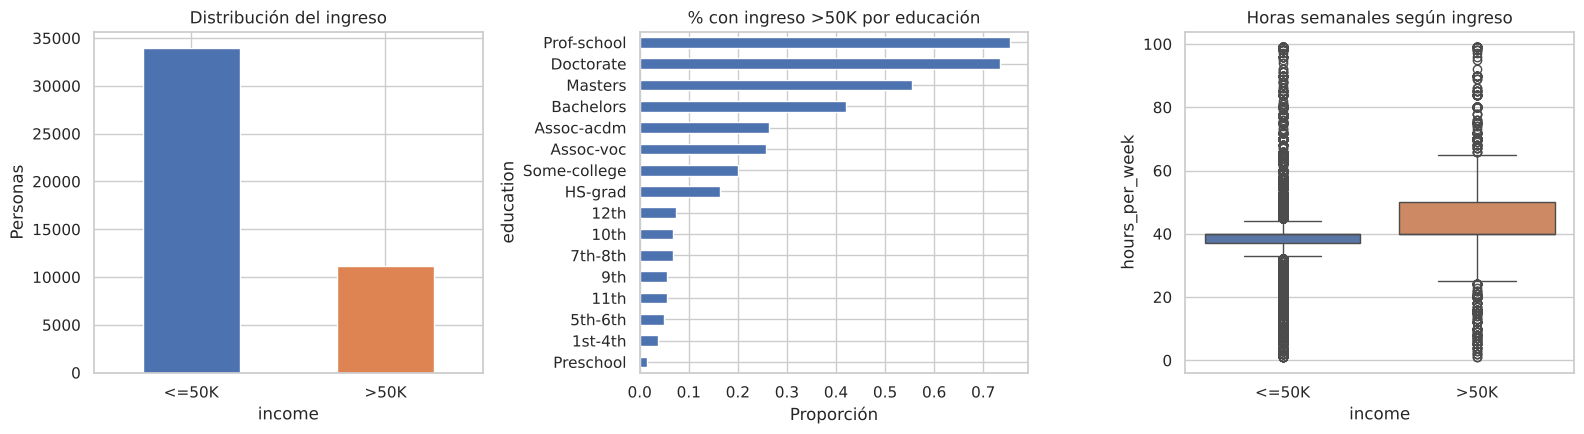

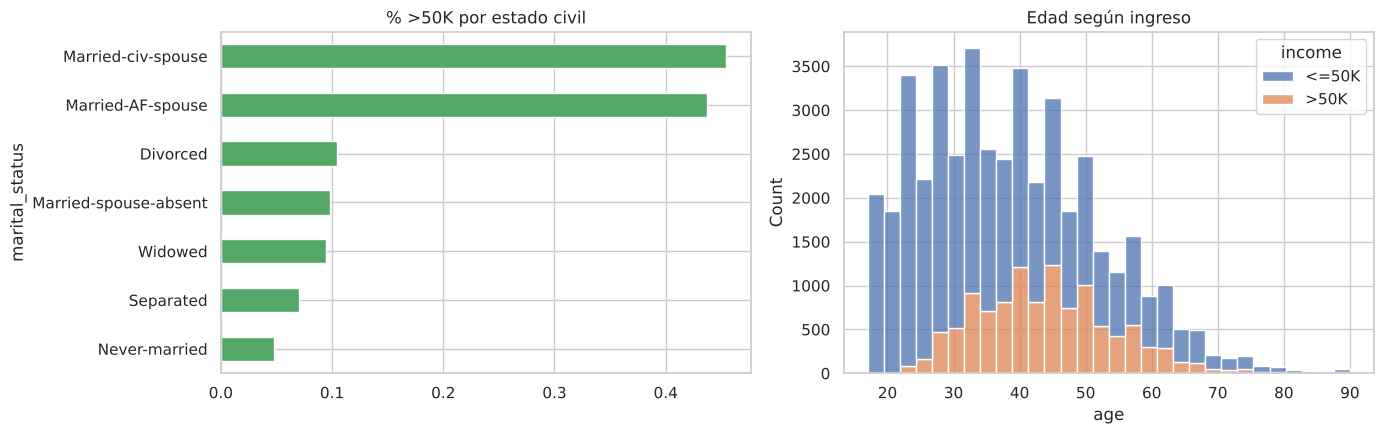

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
# 1) Objetivo
d.income.value_counts().plot.bar(ax=ax[0], color=['#4C72B0','#DD8452'], rot=0)
ax[0].set_title('Distribución del ingreso'); ax[0].set_ylabel('Personas')
# 2) % >50K por nivel educativo
orden = d.groupby('education').income.apply(lambda s: (s=='>50K').mean()).sort_values()
orden.plot.barh(ax=ax[1], color='#4C72B0'); ax[1].set_title('% con ingreso >50K por educación'); ax[1].set_xlabel('Proporción')
# 3) Horas por clase
sns.boxplot(data=d, x='income', y='hours_per_week', ax=ax[2], palette=['#4C72B0','#DD8452'])
ax[2].set_title('Horas semanales según ingreso')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
(d.groupby('marital_status').income.apply(lambda s: (s=='>50K').mean()).sort_values()
  .plot.barh(ax=ax[0], color='#55A868')); ax[0].set_title('% >50K por estado civil')
sns.histplot(data=d, x='age', hue='income', bins=30, ax=ax[1], multiple='stack'); ax[1].set_title('Edad según ingreso')
plt.tight_layout(); plt.show()

**Interpretación del EDA**
- Los datos están **desbalanceados**: ~75 % gana `<=50K` y ~25 % gana `>50K`. Por eso, cualquier regla que apunte a `>50K` debe compararse con ese 25 % base (de ahí la importancia del *lift*).
- **Educación:** hay una escala muy clara. Con estudios hasta secundaria incompleta sólo ~5–7 % supera 50K; con licenciatura sube a ~42 %, con magíster ~55 % y con doctorado o escuela profesional ~75 %.
- **Estado civil:** las personas casadas (cónyuge presente) tienen ~45 % de ingreso alto, contra ~5 % de los nunca casados. Esto probablemente refleja edad y hogares con más de un ingreso, no una causa directa.
- **Horas semanales:** quienes ganan más de 50K tienden a trabajar más horas, aunque hay mucho traslape entre ambos grupos.
- **Edad:** el ingreso alto es raro antes de los 25 y se concentra entre los 35 y 55 años.

## D. Reglas de asociación
**Fase CRISP-DM: Modelado** (apoyada en la Preparación de los datos: discretización y formato de ítems).

### Selección de columnas y preparación
Elegí **7 columnas** (6 predictoras + el ingreso): `edad`, `educacion`, `estado_civil`, `ocupacion`, `horas`, `ganancia_cap` e `ingreso`. Las elegí porque son las que mejor describen el perfil laboral y educativo de la persona, y mantenerlas pocas evita reglas muy largas y repetidas. Dejé fuera `workclass`, `relationship` y `native_country`: `relationship` repite lo que dice `estado_civil` y `native_country` está casi todo en un solo valor (EE.UU.).

**Discretización.** El algoritmo trabaja con ítems presentes o ausentes en cada registro, así que las variables numéricas no se pueden usar tal cual: `age` y `hours_per_week` las agrupé en tramos, y `capital_gain` lo convertí en "con ganancia / sin ganancia" (porque el 92 % tiene 0). Luego todas las categorías se pasan a columnas verdadero/falso (*one-hot*).

In [5]:
educ_grupo = d.education.map(lambda e: 'basica' if e in ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th']
                             else ('superior' if e in ['Bachelors','Masters','Doctorate','Prof-school'] else 'secundaria'))
cat = pd.DataFrame({
    'edad': pd.cut(d.age, [0,25,35,50,100], labels=['joven','adulto_joven','adulto','mayor']),
    'educacion': educ_grupo,
    'estado_civil': d.marital_status,
    'ocupacion': d.occupation,
    'horas': pd.cut(d.hours_per_week, [0,34,40,60,100], labels=['parcial','40h','extra','intenso']),
    'ganancia_cap': np.where(d.capital_gain>0, 'con_ganancia', 'sin_ganancia'),
    'ingreso': d.income})
print("Columnas usadas en las reglas:", cat.shape[1])
oh = pd.get_dummies(cat.astype(str)).astype(bool)
print("Ítems (columnas verdadero/falso):", oh.shape[1])
cat.head()

Columnas usadas en las reglas: 7
Ítems (columnas verdadero/falso): 36


,edad,educacion,estado_civil,ocupacion,horas,ganancia_cap,ingreso
0,adulto,superior,Never-married,Adm-clerical,40h,con_ganancia,<=50K
1,adulto,superior,Married-civ-spouse,Exec-managerial,parcial,sin_ganancia,<=50K
2,adulto,secundaria,Divorced,Handlers-cleaners,40h,sin_ganancia,<=50K
3,mayor,basica,Married-civ-spouse,Handlers-cleaners,40h,sin_ganancia,<=50K
4,adulto_joven,superior,Married-civ-spouse,Prof-specialty,40h,sin_ganancia,<=50K


**Interpretación:** la tabla muestra cada persona ya como categorías (por ejemplo `edad = adulto`, `educacion = superior`). Después del *one-hot* quedan 36 ítems; cada fila indica cuáles están presentes.

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

def reglas(min_sup, min_conf, max_len=3):
    freq = apriori(oh, min_support=min_sup, use_colnames=True, max_len=max_len)
    rules = association_rules(freq, metric='confidence', min_threshold=min_conf)
    r = rules[rules.consequents.apply(lambda c: c == {'ingreso_>50K'})].copy()
    r['regla (si...)'] = r.antecedents.apply(lambda s: ' + '.join(sorted(s)))
    return freq, r.sort_values('lift', ascending=False)

# Prueba de distintos valores de los parámetros
filas = []
for s in (0.02, 0.05, 0.10):
    for c in (0.5, 0.6, 0.7, 0.8):
        f, r = reglas(s, c)
        filas.append({'min_support': s, 'min_confidence': c, 'itemsets frecuentes': len(f), 'reglas hacia >50K': len(r)})
pd.DataFrame(filas).pivot(index='min_support', columns='min_confidence', values='reglas hacia >50K')

min_confidence,0.5,0.6,0.7,0.8
min_support,,,,
0.02,24,13,6,1
0.05,9,5,1,0
0.10,2,1,1,0


**Qué cambió al variar los parámetros** (la tabla muestra cuántas reglas hacia `>50K` salen):
- Con `min_support = 0.02` salen muchas reglas (hasta 24 con confianza 0,5), pero muchas cubren grupos muy pequeños (2 % ≈ 900 personas) y se repiten entre sí.
- Con `min_support = 0.10` casi no quedan reglas (1 o 2): sólo sobreviven los grupos más grandes y se pierde el ingreso alto, que es sólo ~25 % del total.
- Subir `min_confidence` de 0,5 a 0,8 reduce las reglas de forma fuerte: con 0,8 casi no hay ninguna con soporte razonable.

Elegí **`min_support = 0.05` y `min_confidence = 0.60`**: da un conjunto pequeño (5 reglas) que se puede interpretar, cada una cubre al menos ~2.250 personas, y al menos 6 de cada 10 personas del grupo tienen ingreso alto (muy por encima del 25 % base).

In [7]:
freq, r = reglas(0.05, 0.60)
print(f"Itemsets frecuentes: {len(freq)} | Reglas hacia >50K: {len(r)}")
r[['regla (si...)','support','confidence','lift']].round(3).reset_index(drop=True)

Itemsets frecuentes: 303 | Reglas hacia >50K: 5


,regla (si...),support,confidence,lift
0,educacion_superior + estado_civil_Married-civ-...,0.101,0.727,2.933
1,estado_civil_Married-civ-spouse + ocupacion_Ex...,0.053,0.682,2.750
2,ganancia_cap_con_ganancia,0.053,0.627,2.527
3,educacion_superior + horas_extra,0.062,0.621,2.503
4,edad_adulto + educacion_superior,0.066,0.600,2.421


### Tabla de reglas interpretadas (base: ~25 % de la población gana >50K)
| # | Regla (si… entonces ingreso >50K) | Support | Confidence | Lift | Qué significa en lenguaje del negocio | Qué decisión podría apoyar |
|---|---|---|---|---|---|---|
| 1 | Casado + educación superior | 0,101 | 0,727 | 2,93 | El 10 % de las personas cumple ambas condiciones y 7 de cada 10 de ellas gana >50K; es casi 3 veces más probable que en la población general. | Identificar el perfil de ingreso alto más numeroso, por ejemplo para ofrecer productos o servicios dirigidos a ese segmento. |
| 2 | Casado + ocupación directiva (Exec-managerial) | 0,053 | 0,682 | 2,75 | Los directivos casados son un grupo pequeño (5 %) pero casi 7 de cada 10 gana >50K. | Definir criterios de segmentación para programas de ascenso o formación en gestión. |
| 3 | Con ganancia de capital | 0,053 | 0,627 | 2,53 | Quien declara ganancias de inversión tiene 2,5 veces más probabilidad de ingreso alto; es un grupo pequeño (5 %). | Detectar personas con capacidad de inversión para ofertas de asesoría financiera. |
| 4 | Educación superior + horas extra (41–60 h) | 0,062 | 0,621 | 2,50 | Con estudios superiores y jornada extendida, 6 de cada 10 supera 50K. | Mostrar que la educación superior combinada con mayor dedicación se asocia a mejores ingresos; útil para orientación laboral. |
| 5 | Edad adulta (36–50) + educación superior | 0,066 | 0,600 | 2,42 | A esa edad, con estudios superiores, el 60 % gana >50K. | Orientar políticas de retención o desarrollo de profesionales en etapa media de carrera. |

**Lectura general:** todas las reglas tienen lift mucho mayor que 1, es decir, no son azar frente al 25 % base. **Educación superior** aparece en 3 de las 5 reglas y **estado civil casado** en 2. Una regla muestra *asociación*, no causa: "casado" probablemente refleja edad y hogares con dos ingresos. Si lo que importa es el lift y no el tamaño del grupo, bajar el soporte a 0,02 con confianza 0,8 revela una regla más específica ({con ganancia de capital + educación superior}, confianza 0,83, lift 3,3) pero cubre sólo ~3 % de las personas.

## E. Árbol de decisión
**Fase CRISP-DM: Modelado.**

**Variable objetivo:** `income` (categórica, 2 clases: `<=50K` y `>50K`). **Columnas descartadas:** `fnlwgt` (peso estadístico del censo, no es información de la persona), `education_num` (repite `education`) y `race`/`sex` (atributos sensibles). El dataset no trae nombres ni identificadores, así que no había que quitar ID. Para el árbol dejé 10 variables: `edad`, `horas`, `ganancia_cap`, `perdida_cap`, `casado`, `educ_superior`, `directivo_prof`, `pais_eeuu`, `trab_privado` y `cuenta_propia`.

**Revisión de fuga de información.** Una columna casi equivalente al objetivo haría que el árbol la use sin aportar conocimiento. Lo detecto mirando que ninguna variable separe las clases casi perfectamente: reviso la tasa de `>50K` por valor de cada variable binaria y la importancia que el árbol les asigna (si una sola tuviera ~100 % de importancia o diera hojas casi puras desde la raíz, sería sospechosa).

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X = pd.DataFrame({
    'edad': d.age,
    'horas': d.hours_per_week,
    'ganancia_cap': (d.capital_gain>0).astype(int),
    'perdida_cap': (d.capital_loss>0).astype(int),
    'casado': (d.marital_status=='Married-civ-spouse').astype(int),
    'educ_superior': d.education.isin(['Bachelors','Masters','Doctorate','Prof-school']).astype(int),
    'directivo_prof': d.occupation.isin(['Exec-managerial','Prof-specialty']).astype(int),
    'pais_eeuu': (d.native_country=='United-States').astype(int),
    'trab_privado': (d.workclass=='Private').astype(int),
    'cuenta_propia': d.workclass.str.startswith('Self').astype(int)})
y = d.income

# Chequeo de fuga: % de >50K cuando cada indicador vale 1
bin_cols = [c for c in X.columns if X[c].nunique()==2]
print((X[bin_cols].apply(lambda col: (y[col==1]=='>50K').mean())).round(2).sort_values(ascending=False))

ganancia_cap      0.63
perdida_cap       0.51
educ_superior     0.49
directivo_prof    0.46
casado            0.45
cuenta_propia     0.36
pais_eeuu         0.25
trab_privado      0.22
dtype: float64


**Interpretación:** ninguna variable llega cerca de 100 %: la más alta es `ganancia_cap` (~63 % de >50K entre quienes tienen ganancia). Ninguna columna "adivina" el ingreso, así que no hay fuga de información evidente.

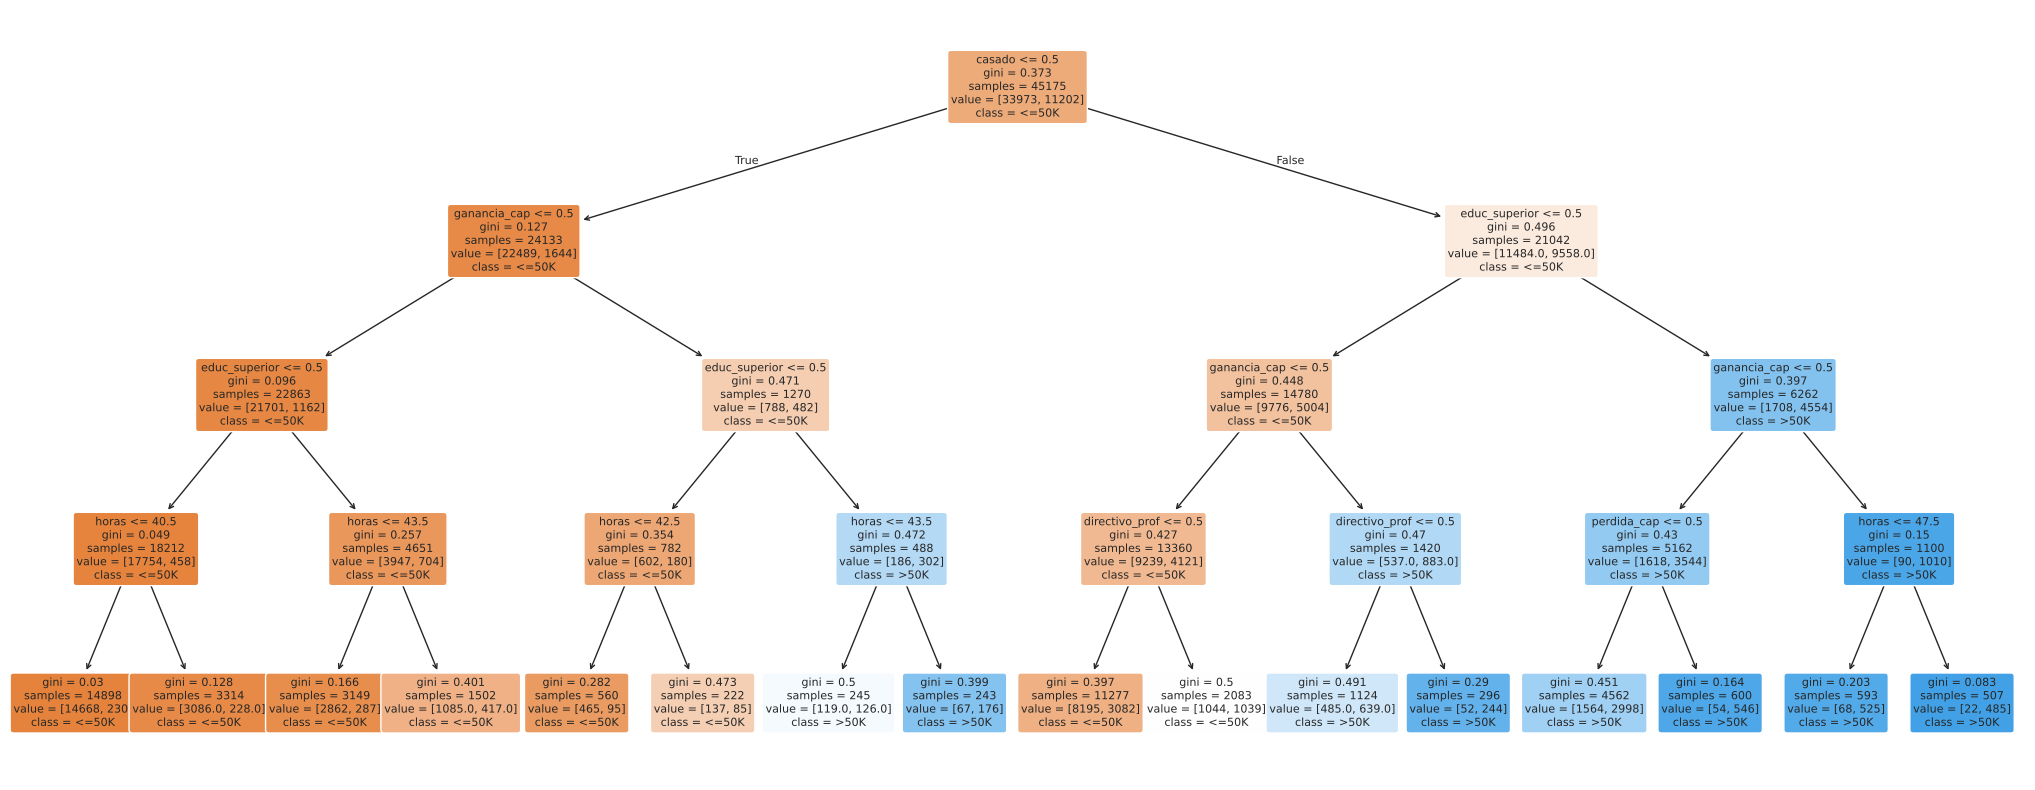

|--- casado <= 0.50
|   |--- ganancia_cap <= 0.50
|   |   |--- educ_superior <= 0.50
|   |   |   |--- horas <= 40.50
|   |   |   |   |--- weights: [14668.00, 230.00] class: <=50K
|   |   |   |--- horas >  40.50
|   |   |   |   |--- weights: [3086.00, 228.00] class: <=50K
|   |   |--- educ_superior >  0.50
|   |   |   |--- horas <= 43.50
|   |   |   |   |--- weights: [2862.00, 287.00] class: <=50K
|   |   |   |--- horas >  43.50
|   |   |   |   |--- weights: [1085.00, 417.00] class: <=50K
|   |--- ganancia_cap >  0.50
|   |   |--- educ_superior <= 0.50
|   |   |   |--- horas <= 42.50
|   |   |   |   |--- weights: [465.00, 95.00] class: <=50K
|   |   |   |--- horas >  42.50
|   |   |   |   |--- weights: [137.00, 85.00] class: <=50K
|   |   |--- educ_superior >  0.50
|   |   |   |--- horas <= 43.50
|   |   |   |   |--- weights: [119.00, 126.00] class: >50K
|   |   |   |--- horas >  43.50
|   |   |   |   |--- weights: [67.00, 176.00] class: >50K
|--- casado >  0.50
|   |--- educ_superior <

In [9]:
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=200, random_state=42).fit(X, y)

plt.figure(figsize=(26, 10))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True, rounded=True, fontsize=8)
plt.show()
print(export_text(tree, feature_names=list(X.columns), show_weights=True))

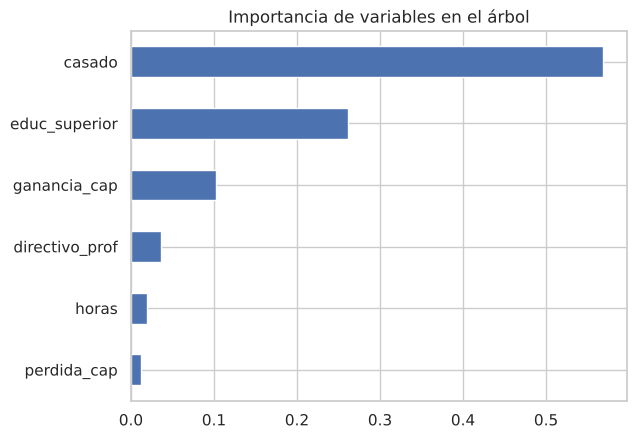

max_depth=4: profundidad real=4, hojas=16


max_depth=8: profundidad real=8, hojas=220
max_depth=None: profundidad real=29, hojas=6523


In [10]:
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
imp[imp>0].round(3).plot.barh(color='#4C72B0').invert_yaxis()
plt.title('Importancia de variables en el árbol'); plt.show()

# ¿Qué pasaría con un árbol mucho más profundo?
for md_ in (4, 8, None):
    t = DecisionTreeClassifier(max_depth=md_, random_state=42).fit(X, y)
    print(f"max_depth={md_}: profundidad real={t.get_depth()}, hojas={t.get_n_leaves()}")

**Atributo de la raíz.** La raíz es `casado`. El árbol elige primero la variable que mejor separa a las personas de ingreso alto y bajo; `casado` es la que más reduce la mezcla de clases en un solo corte (≈57 % de la importancia total), seguida de `educ_superior` (≈26 %) y `ganancia_cap` (≈10 %). Esto coincide con las reglas de la parte D.

**Caminos del árbol traducidos a reglas de negocio** (cada par es [personas ≤50K, personas >50K] de la hoja):
1. **Casado + educación superior + sin ganancia ni pérdida de capital → >50K.** Hoja [1.564 ; 2.998]: el 66 % gana >50K. *Regla de negocio:* las personas casadas con estudios superiores forman el grupo de ingreso alto más numeroso.
2. **Casado + educación superior + con ganancia de capital → >50K.** Hojas con 88–96 % de >50K (por ejemplo [22 ; 485]). *Regla de negocio:* si además invierten, casi todas superan 50K.
3. **No casado + sin ganancia de capital + sin educación superior + trabaja ≤40 h → ≤50K.** Hoja [14.668 ; 230]: sólo 1,5 % gana >50K. *Regla de negocio:* es el grupo más grande y de menor ingreso.
4. **Casado + sin educación superior + sin ganancia de capital + ocupación no directiva/profesional → ≤50K.** Hoja [8.195 ; 3.082]: 73 % gana ≤50K, aunque 27 % sí supera 50K.

**Decisión que podría apoyar el árbol:** priorizar a quiénes dirigir programas de capacitación (el grupo del camino 3 es el mayor y de menor ingreso) y poder clasificar a una persona nueva en uno de los grupos según estado civil, educación y ganancias de capital.

**Por qué profundidad 4.** Con 4 niveles el árbol tiene 16 hojas y se puede leer completo como reglas de negocio. Al dejarlo sin límite llega a profundidad 29 y a más de 6.500 hojas (con profundidad 8 ya son 220): cada hoja agrupa poquísimas personas, se vuelve ilegible y estaría *memorizando* casos particulares (sobreajuste) en lugar de mostrar patrones generales. Además exigí 200 personas mínimas por hoja para que cada regla tenga respaldo.

## F. Síntesis y proceso CRISP-DM
**Fase CRISP-DM: esta parte revisa todas.**

### Comparación de las dos representaciones
| Aspecto | Reglas de asociación | Árbol de decisión |
|---|---|---|
| Qué conocimiento aporta | Combinaciones frecuentes de características con alto lift hacia `>50K` (perfiles) | Estructura jerárquica que clasifica a *todas* las personas y muestra qué variable pesa primero |
| Cuándo usarla | Para describir perfiles ("¿quiénes tienden a ganar más?") | Para segmentar o decidir ("¿a qué grupo pertenece esta persona?") |
| Limitaciones con este dataset | Sólo cubre grupos sobre el soporte mínimo; reglas muy parecidas entre sí (1 y 5 comparten educación superior); depende de cómo agrupé edad y horas | Depende de los cortes elegidos; con profundidad 4 simplifica; con el desbalance 75/25 la mayoría de las hojas terminan en `<=50K` |

**Limitaciones generales:** los datos son de un censo estadounidense de 1994 y no representan la realidad actual ni la chilena; "casado" mezcla efectos de edad y hogar; las asociaciones no implican causalidad; y el ingreso está dicotomizado en ≤50K / >50K.

### Tabla de fases de CRISP-DM
| Fase | Qué hice / qué propondría | Parte |
|---|---|---|
| 1. Comprensión del negocio | Definí el problema y la decisión que se apoya | A |
| 2. Comprensión de los datos | Elegí Adult, documenté fuente y atributos, exploré distribuciones | B y C |
| 3. Preparación de los datos | Eliminé duplicados y faltantes, descarté columnas, discreticé numéricas y creé indicadores | C y D |
| 4. Modelado | Apriori para reglas de asociación y árbol de profundidad 4 | D y E |
| 5. Evaluación | Interpreté support/confidence/lift y los caminos del árbol y los comparé; *propondría además* validar con un conjunto de prueba (ver abajo) | D, E y F |
| 6. Despliegue | No se realizó; propuesta abajo | F |

### Propuesta de evaluación y puesta en uso
- **Evaluación:** pediría a un experto del área (por ejemplo, un orientador laboral) que revise si las reglas tienen sentido; separaría un conjunto de prueba para comprobar que las reglas y el árbol se mantienen con datos que no se usaron al construirlos; y repetiría el análisis con datos más recientes para ver si los patrones siguen vigentes.
- **Puesta en uso:** presentar los perfiles de las reglas y el árbol (ya legible) en un informe o tablero a quienes diseñan programas de capacitación, usándolos para priorizar a qué grupos dirigirlos. Revisaría los resultados cada cierto tiempo con datos nuevos y no usaría el modelo para decisiones individuales sobre personas, sólo para segmentos.

## G. Autoría y uso de herramientas

**Repositorio GitHub con este notebook sincronizado:** [https://github.com/xXElGrisXx/1.9](https://github.com/xXElGrisXx/1.9)

**Declaración de autoría.** Declaro que este trabajo es de mi autoría y que puedo explicar cada una de sus partes. Las tareas realizadas incluyen: proponer y seleccionar el dataset, estructurar el notebook, generar el código base y redactar un primer borrador de los textos.   
**Uso de IA:** se utilizó inteligencia artificial únicamente como apoyo para resolver dudas puntuales sobre el código y mejorar la redacción de algunos apartados.

**Fuente y licencia del dataset.** Becker, B. & Kohavi, R. (1996). *Adult* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5XW20](https://doi.org/10.24432/C5XW20) — Licencia CC BY 4.0.

**Mi aprendizaje principal.** Con el dataset *Adult* aprendí que el ingreso alto no depende de una sola variable, sino de combinaciones: estar casado, tener educación superior y declarar ganancias de capital aumentan significativamente la probabilidad de superar los 50K (lift cercano a 3 frente al 25 % base). También comprendí que las reglas de asociación describen perfiles y el árbol de decisión clasifica, mostrando correlaciones pero no causas. Por ejemplo, la condición “casado” probablemente refleja edad y hogares con dos ingresos. Finalmente, confirmé la importancia de la limpieza de datos: los valores nulos aparecían como “?”, y sin revisarlos habría trabajado con información mal interpretada.


